# E3 — Implementación y evaluación de modelos
En este notebook se implementan y evalúan cuatro enfoques para el análisis y predicción de diabetes. Primero se aplica K-Means para identificar perfiles de riesgo en la población. Después se comparan seis variantes de SMOTE sobre un árbol de decisión base para seleccionar la técnica de balanceo más efectiva para el desbalance del dataset. Con la mejor variante de SMOTE, se entrenan y comparan tres clasificadores supervisados Árbol de Decisión, KNN y XGBoost. Despues, se selecciona el mejor mediante AUC. Finalmente, se ajusta el umbral de decisión del mejor modelo con F2-score, que toma el recall con el doble de peso que la precisión, lo cual da mayor importancia en la detección de casos positivos.

Estas tareas mayormente se repiten sobre el dataset enriquecido con variables de actividad física y marcadores de sangre.

### Carga de los archivos

Sube los dos CSV generados en el entregable anterior: mineria_principal.csv y mineria_enriquecido.csv


## Importar librerias


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             accuracy_score, recall_score, precision_score,
                             f1_score, fbeta_score, silhouette_score)

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE, SMOTENC
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

SEMILLA = 42
np.random.seed(SEMILLA)


## Paso 1. Carga de datos y particion train/val/test

Se usa el dataset principal (mineria_principal.csv). Para el threshold tuning se necesita un conjunto de validacion independiente, asi que se divide en:
- 60 % entrenamiento
- 20 % validacion
- 20 % prueba

No se utiliza el de prueba al buscar hiperparametros para evitar sobreajuste.
Las particiones son estratificadas (preservan la proporcion de clases) y con
semilla fija.


In [41]:
proc = pd.read_csv('mineria_principal.csv')
X = proc.drop(columns='diabetes').values
y = proc['diabetes'].values
columnas = list(proc.drop(columns='diabetes').columns)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=SEMILLA)
print('Train:', X_train.shape, ', Val:', X_val.shape, ', Test:', X_test.shape)


Train: (5967, 22) , Val: (1989, 22) , Test: (1989, 22)


## Paso 2. K-Means exploratorio sobre el dataset principal

K-Means es un algoritmo no supervisado: agrupa a las personas por
similitud sin usar la etiqueta de diabetes. Se aplica antes del modelado para
descubrir si existen perfiles naturales de mayor o menor riesgo en la
poblacion.


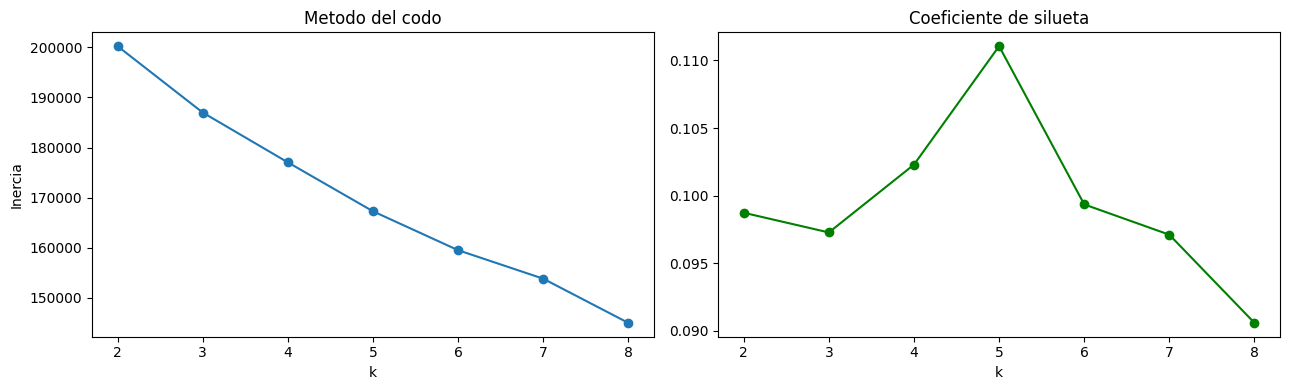

In [42]:
# K-Means requiere datos imputados y escalados (se basa en distancias).
X_full = SimpleImputer(strategy='median').fit_transform(X)
X_full_s = StandardScaler().fit_transform(X_full)

# Buscamos el numero optimo de clusters con el metodo del codo y la silueta.
inercias, siluetas = [], []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(X_full_s)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_full_s, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inercias, 'o-'); axes[0].set_title('Metodo del codo')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(list(ks), siluetas, 'o-', color='green')
axes[1].set_title('Coeficiente de silueta'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()


In [43]:
# Elegimos k segun la mejor silueta
k_optimo = list(ks)[int(np.argmax(siluetas))]
print('k elegido:', k_optimo)
kmeans = KMeans(n_clusters=k_optimo, random_state=SEMILLA, n_init=10).fit(X_full_s)

perfil = pd.DataFrame({
    'cluster': kmeans.labels_,
    'diabetes': y,
    'edad':    proc['edad'],
    'imc':     proc['imc'],
    'cintura': proc['cintura'],
})
agrupado = perfil.groupby('cluster').agg(
    personas=('diabetes', 'size'),
    tasa_diabetes=('diabetes', lambda x: round(100*x.mean(), 2)),
    edad_media=('edad', 'mean'),
    imc_medio=('imc', 'mean'),
    cintura_media=('cintura', 'mean'),
).round(2).sort_values('tasa_diabetes', ascending=False)
agrupado


k elegido: 5


,personas,tasa_diabetes,edad_media,imc_medio,cintura_media
cluster,,,,,
0,1625,27.69,53.80,31.74,102.92
4,161,27.33,54.54,29.48,96.25
3,4615,11.18,46.90,28.51,92.84
1,3495,9.24,45.99,29.52,100.59
2,49,4.08,33.96,32.38,98.69


**Interpretacion.** Si algun cluster concentra una tasa de diabetes muy
superior al promedio (~13 %), K-Means habra identificado un **perfil de
riesgo** (tipicamente: mayor edad, IMC y cintura). Esto aporta valor
descriptivo aunque K-Means no sea un clasificador.


## Paso 3. Preprocesamiento (imputacion)

Imputamos los valores faltantes con la mediana **solo con datos de
entrenamiento** y aplicamos la misma transformacion a validacion y prueba
(asi no hay fuga de informacion del test hacia el train).


In [44]:
imputador = SimpleImputer(strategy='median').fit(X_train)
X_train_i = imputador.transform(X_train)
X_val_i   = imputador.transform(X_val)
X_test_i  = imputador.transform(X_test)


## Paso 4. Comparacion de las 6 variantes de SMOTE

Para tratar el desbalance de clases probamos seis variantes de SMOTE. Cada una balancea el conjunto de entrenamiento de forma distinta. Las evaluamos con un arbol de decision base para que la unica diferencia sea la SMOTE.

La metrica de eleccion es AUC en validacion: nos interesa la variante que
mejor permite al modelo separar las clases, independiente del umbral.

In [45]:
# Indices de las 12 variables binarias del dataset (para SMOTE-NC)
CAT_IDX = [columnas.index(c) for c in ['mujer', 'hipertension', 'colesterol_alto',
    'trigliceridos_altos', 'enf_renal_a', 'enf_renal_b', 'enf_renal_c',
    'fuma_actualmente', 'fumo_en_pasado','gano_peso', 'perdio_peso']]

VARIANTES_SMOTE = {
    'SMOTE'          : SMOTE(random_state=SEMILLA),
    'ADASYN'         : ADASYN(random_state=SEMILLA),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=SEMILLA),
    'SMOTE-NC'       : SMOTENC(categorical_features=CAT_IDX, random_state=SEMILLA),
    'SMOTE-ENN'      : SMOTEENN(random_state=SEMILLA),
    'SMOTE-Tomek'    : SMOTETomek(random_state=SEMILLA),
}

resultados_smote = {}
for nombre, variante in VARIANTES_SMOTE.items():
    X_bal, y_bal = variante.fit_resample(X_train_i, y_train)
    modelo = DecisionTreeClassifier(random_state=SEMILLA)
    modelo.fit(X_bal, y_bal)
    proba_val = modelo.predict_proba(X_val_i)[:, 1]
    pred_val  = (proba_val >= 0.5).astype(int)
    resultados_smote[nombre] = {
        'AUC':       roc_auc_score(y_val, proba_val),
        'Recall':    recall_score(y_val, pred_val),
        'Precision': precision_score(y_val, pred_val),
        'F1':        f1_score(y_val, pred_val),
        'F2':        fbeta_score(y_val, pred_val, beta=2),
    }
    print(f'{nombre:18s}  AUC val={resultados_smote[nombre]["AUC"]:.3f}')

SMOTE               AUC val=0.622
ADASYN              AUC val=0.569
BorderlineSMOTE     AUC val=0.612
SMOTE-NC            AUC val=0.575
SMOTE-ENN           AUC val=0.651
SMOTE-Tomek         AUC val=0.623


In [46]:
tabla_smote = pd.DataFrame(resultados_smote).T.round(3).sort_values('AUC', ascending=False)
tabla_smote

,AUC,Recall,Precision,F1,F2
SMOTE-ENN,0.651,0.528,0.267,0.354,0.441
SMOTE-Tomek,0.623,0.371,0.314,0.340,0.358
SMOTE,0.622,0.378,0.305,0.338,0.361
BorderlineSMOTE,0.612,0.352,0.297,0.322,0.340
SMOTE-NC,0.575,0.285,0.246,0.264,0.276
ADASYN,0.569,0.281,0.233,0.255,0.270


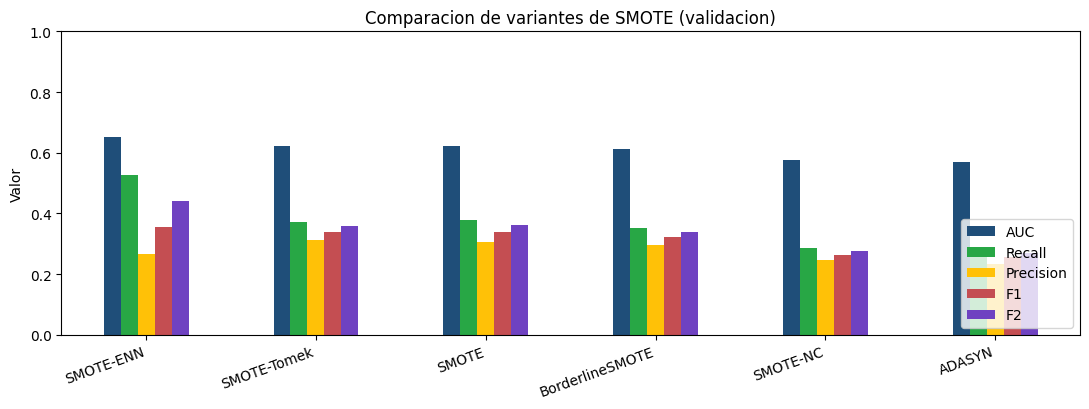

In [47]:
fig, ax = plt.subplots(figsize=(11, 4.2))
tabla_smote.plot(kind='bar', ax=ax,
                 color=['#1F4E79','#28A745','#FFC107','#C44E52','#6F42C1'])
ax.set_title('Comparacion de variantes de SMOTE (validacion)')
ax.set_xticklabels(tabla_smote.index, rotation=20, ha='right')
ax.set_ylabel('Valor'); ax.set_ylim(0, 1); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


La tecnica que se eligio para el desbalance es el SMOTE-ENN, el cual es la combinacion SMOTE + Edited Nearest Neighbors: primero sobremuestrea
y despues limpia los puntos sinteticos cuya clase no concuerda con la de sus
vecinos. Por eso suele dar mejores metricas que SMOTE clasico en problemas
con frontera ruidosa, como el nuestro.

## Paso 5. Comparacion de algoritmos supervisados

Entrenamos cuatro modelos sobre el mismo conjunto de entrenamiento y los
evaluamos sobre el de prueba.

- **5.1 Arbol simple**: linea base, sin SMOTE ni tuning.
- **5.2 Arbol ajustado**: SMOTE-ENN + GridSearch por AUC.
- **5.3 KNN**: SMOTE-ENN + GridSearch por AUC (necesita escalado).
- **5.4 XGBoost**: SMOTE-ENN + GridSearch por AUC.


In [48]:
# Diccionario donde acumulamos las probabilidades de prueba de cada modelo
proba_modelos = {}
resultados_modelos = {}

def registrar(nombre, proba_test):
    proba_modelos[nombre] = proba_test
    pred = (proba_test >= 0.5).astype(int)
    resultados_modelos[nombre] = {
        'AUC':       roc_auc_score(y_test, proba_test),
        'Recall':    recall_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'F2':        fbeta_score(y_test, pred, beta=2),
    }
    print(f'{nombre}  AUC test={resultados_modelos[nombre]["AUC"]:.3f}  '
          f'Recall={resultados_modelos[nombre]["Recall"]:.3f}  '
          f'Precision={resultados_modelos[nombre]["Precision"]:.3f}')


### 5.1 Arbol simple (linea base)


In [49]:
arbol_simple = DecisionTreeClassifier(random_state=SEMILLA)
arbol_simple.fit(X_train_i, y_train)
proba_arbol_simple = arbol_simple.predict_proba(X_test_i)[:, 1]
registrar('1. Arbol simple', proba_arbol_simple)


1. Arbol simple  AUC test=0.597  Recall=0.330  Precision=0.274


### 5.2 Arbol ajustado (SMOTE-ENN + GridSearch AUC)


In [50]:
pipe_arbol = ImbPipeline([
    ('smote',  SMOTEENN(random_state=SEMILLA)),
    ('modelo', DecisionTreeClassifier(random_state=SEMILLA)),
])
malla_arbol = {
    'modelo__max_depth':       [3, 5, 7, 10, 15],
    'modelo__min_samples_leaf':[1, 10, 25, 50],
    'modelo__criterion':       ['gini', 'entropy'],
}
busq_arbol = GridSearchCV(pipe_arbol, malla_arbol, scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA),
                          n_jobs=-1)
busq_arbol.fit(X_train_i, y_train)
print('Mejores hiperparametros arbol:', busq_arbol.best_params_)
proba_arbol_tuneado = busq_arbol.best_estimator_.predict_proba(X_test_i)[:, 1]
registrar('2. Arbol ajustado + SMOTE-ENN', proba_arbol_tuneado)


Mejores hiperparametros arbol: {'modelo__criterion': 'entropy', 'modelo__max_depth': 10, 'modelo__min_samples_leaf': 50}
2. Arbol ajustado + SMOTE-ENN  AUC test=0.785  Recall=0.685  Precision=0.293


### 5.3 KNN (SMOTE-ENN + escalado + GridSearch AUC)


In [51]:
pipe_knn = ImbPipeline([
    ('smote',   SMOTEENN(random_state=SEMILLA)),
    ('escalar', StandardScaler()),
    ('modelo',  KNeighborsClassifier()),
])
malla_knn = {
    'modelo__n_neighbors': [5, 7, 21, 31, 51],
    'modelo__weights':     ['uniform', 'distance'],
}
busq_knn = GridSearchCV(pipe_knn, malla_knn, scoring='roc_auc',
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA),
                        n_jobs=-1)
busq_knn.fit(X_train_i, y_train)
print('Mejores hiperparametros KNN:', busq_knn.best_params_)
proba_knn = busq_knn.best_estimator_.predict_proba(X_test_i)[:, 1]
registrar('3. KNN + SMOTE-ENN', proba_knn)


Mejores hiperparametros KNN: {'modelo__n_neighbors': 51, 'modelo__weights': 'distance'}
3. KNN + SMOTE-ENN  AUC test=0.790  Recall=0.876  Precision=0.230


### 5.4 XGBoost (SMOTE-ENN + GridSearch AUC)


In [52]:
pipe_xgb = ImbPipeline([
    ('smote',  SMOTEENN(random_state=SEMILLA)),
    ('modelo', XGBClassifier(random_state=SEMILLA, eval_metric='logloss',
                              verbosity=0)),
])
malla_xgb = {
    'modelo__n_estimators':  [100, 200],
    'modelo__max_depth':     [3, 4, 5],
    'modelo__learning_rate': [0.05, 0.1],
}
busq_xgb = GridSearchCV(pipe_xgb, malla_xgb, scoring='roc_auc',
                        cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA),
                        n_jobs=-1)
busq_xgb.fit(X_train_i, y_train)
print('Mejores hiperparametros XGBoost:', busq_xgb.best_params_)
proba_xgb = busq_xgb.best_estimator_.predict_proba(X_test_i)[:, 1]
registrar('4. XGBoost + SMOTE-ENN', proba_xgb)


Mejores hiperparametros XGBoost: {'modelo__learning_rate': 0.1, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}
4. XGBoost + SMOTE-ENN  AUC test=0.817  Recall=0.697  Precision=0.332


## Paso 6. Comparativa de algoritmos supervisados


In [53]:
tabla_modelos = pd.DataFrame(resultados_modelos).T.round(3).sort_values('AUC', ascending=False)
tabla_modelos


,AUC,Recall,Precision,F1,F2
4. XGBoost + SMOTE-ENN,0.817,0.697,0.332,0.449,0.571
3. KNN + SMOTE-ENN,0.790,0.876,0.230,0.365,0.561
2. Arbol ajustado + SMOTE-ENN,0.785,0.685,0.293,0.410,0.540
1. Arbol simple,0.597,0.330,0.274,0.299,0.317


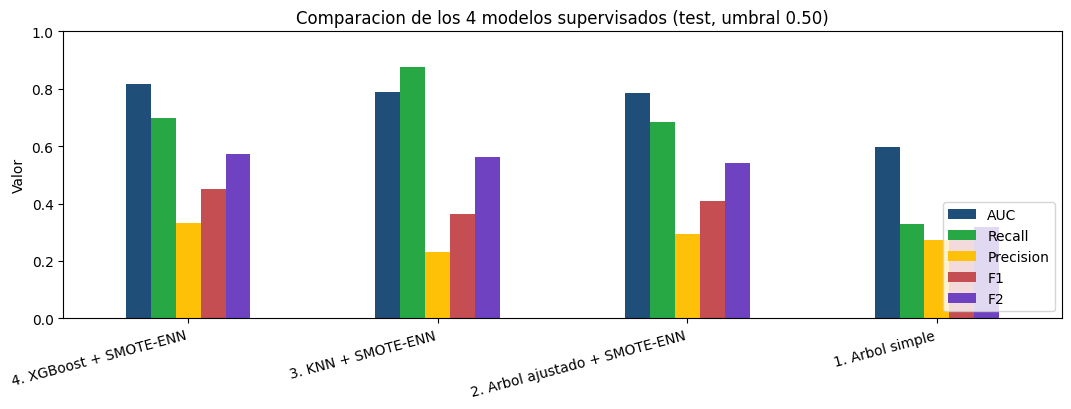

In [54]:
fig, ax = plt.subplots(figsize=(11, 4.2))
tabla_modelos.plot(kind='bar', ax=ax,
                   color=['#1F4E79','#28A745','#FFC107','#C44E52','#6F42C1'])
ax.set_title('Comparacion de los 4 modelos supervisados (test, umbral 0.50)')
ax.set_xticklabels(tabla_modelos.index, rotation=15, ha='right')
ax.set_ylim(0, 1); ax.legend(loc='lower right'); ax.set_ylabel('Valor')
plt.tight_layout(); plt.show()


### Modelo elegido: XGBoost

XGBoost obtuvo la mayor AUC sobre prueba, la mayor F1 y la mayor F2 entre los
cuatro modelos. A diferencia del arbol unico (que produce solo unos pocos
valores de probabilidad), XGBoost combina cientos de arboles internos y da
probabilidades continuas, lo que permitira ajustar el umbral con precision
en los siguientes pasos.


In [55]:
modelo_final = busq_xgb.best_estimator_
proba_test_final  = modelo_final.predict_proba(X_test_i)[:, 1]
proba_val_final   = modelo_final.predict_proba(X_val_i)[:, 1]

## Paso 7. Importancia de atributos y regla IF-THEN

1. Importancia de atributos del XGBoost
2. Regla IF-THEN extraida del arbol ajustado (interpretabilidad: el protocolo del proyecto pide poder leer las reglas del modelo).


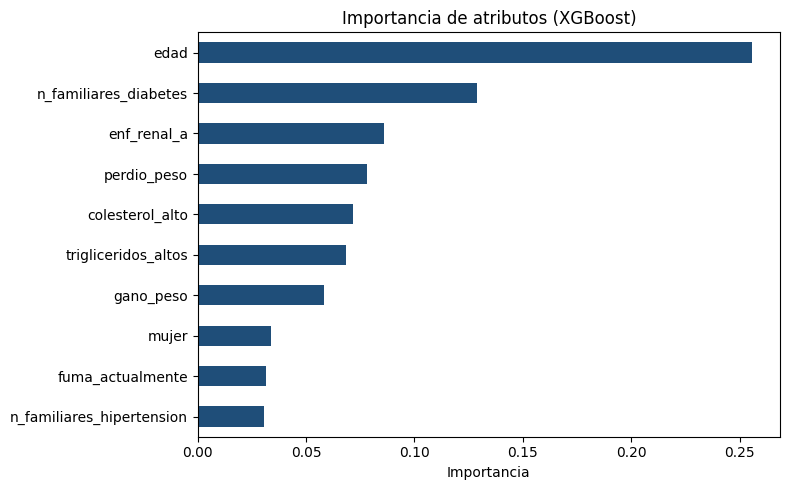

edad                         0.256
n_familiares_diabetes        0.129
enf_renal_a                  0.086
perdio_peso                  0.078
colesterol_alto              0.071
trigliceridos_altos          0.069
gano_peso                    0.058
mujer                        0.034
fuma_actualmente             0.031
n_familiares_hipertension    0.031
dtype: float32


In [56]:
# Importancia del XGBoost
importancias_xgb = pd.Series(
    modelo_final.named_steps['modelo'].feature_importances_,
    index=columnas).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importancias_xgb.head(10).plot(kind='barh', color='#1F4E79')
plt.gca().invert_yaxis()
plt.title('Importancia de atributos (XGBoost)')
plt.xlabel('Importancia')
plt.tight_layout(); plt.show()
print(importancias_xgb.head(10).round(3))


In [57]:
# Regla IF-THEN extraida del arbol ajustado
arbol_ajustado = busq_arbol.best_estimator_.named_steps['modelo']
print(export_text(arbol_ajustado, feature_names=columnas, max_depth=3))


|--- edad <= 42.01
|   |--- edad <= 33.18
|   |   |--- n_familiares_diabetes <= 0.37
|   |   |   |--- class: 0
|   |   |--- n_familiares_diabetes >  0.37
|   |   |   |--- perdio_peso <= 0.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- perdio_peso >  0.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- edad >  33.18
|   |   |--- perdio_peso <= 0.00
|   |   |   |--- cintura <= 97.90
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- cintura >  97.90
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- perdio_peso >  0.00
|   |   |   |--- perdio_peso <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- perdio_peso >  1.00
|   |   |   |   |--- truncated branch of depth 3
|--- edad >  42.01
|   |--- n_familiares_diabetes <= 0.00
|   |   |--- perdio_peso <= 0.01
|   |   |   |--- edad <= 62.00
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- edad >  62.00
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- pe

Las variables más relevantes son la edad y los antecedentes familiares. Esto ya se había observado durante el EDA, donde se pudo ver una mayor concentración de casos en personas de ciertos rangos de edad y en personas con antecedentes familiares.

## Paso 8. Ajuste del umbral de decision con F2
En este problema:

- Un falso negativo (no detectar a una persona con diabetes) es más grave que un falso positivo (realizar una prueba de confirmación adicional). Aunque el recall es la métrica más importante, también es necesario evitar una cantidad excesiva de falsos positivos.
- Por eso preferimos elegir el umbral que maximiza el F2-score (pondera el recall 4x sobre la precision), calculado sobre el conjunto de validacion.


Umbral F2-optimo (validacion): 0.385


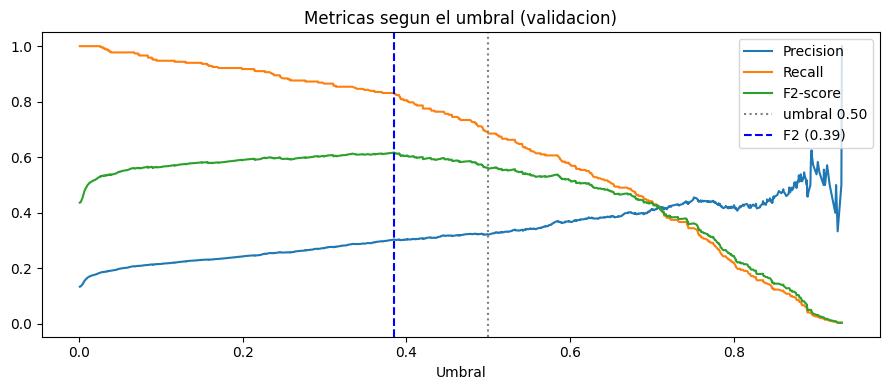

In [58]:
prec, rec, umbrales = precision_recall_curve(y_val, proba_val_final)
f2 = (5 * prec * rec) / (4 * prec + rec + 1e-9)
UMBRAL_F2 = float(umbrales[int(np.argmax(f2[:-1]))])
print(f'Umbral F2-optimo (validacion): {UMBRAL_F2:.3f}')

plt.figure(figsize=(9, 4))
plt.plot(umbrales, prec[:-1], label='Precision')
plt.plot(umbrales, rec[:-1],  label='Recall')
plt.plot(umbrales, f2[:-1],   label='F2-score')
plt.axvline(0.50,      color='gray', linestyle=':',  label='umbral 0.50')
plt.axvline(UMBRAL_F2, color='blue', linestyle='--', label=f'F2 ({UMBRAL_F2:.2f})')
plt.xlabel('Umbral'); plt.title('Metricas segun el umbral (validacion)')
plt.legend(loc='best'); plt.tight_layout(); plt.show()


## Paso 9. Evaluacion final sobre prueba — Dataset principal

Reportamos los resultados con tres umbrales:

- 0.50: el por defecto, equilibrio entre precision y recall.
- F2-optimo: el calculado en el paso anterior.


In [59]:
for u in [0.50, UMBRAL_F2]:
    pred = (proba_test_final >= u).astype(int)
    print('=' * 60)
    print(f'Umbral {u:.2f}')
    print(classification_report(y_test, pred,
                                target_names=['No diabetes', 'Diabetes']))


Umbral 0.50
              precision    recall  f1-score   support

 No diabetes       0.94      0.78      0.86      1722
    Diabetes       0.33      0.70      0.45       267

    accuracy                           0.77      1989
   macro avg       0.64      0.74      0.65      1989
weighted avg       0.86      0.77      0.80      1989

Umbral 0.39
              precision    recall  f1-score   support

 No diabetes       0.95      0.71      0.81      1722
    Diabetes       0.29      0.76      0.42       267

    accuracy                           0.72      1989
   macro avg       0.62      0.73      0.61      1989
weighted avg       0.86      0.72      0.76      1989



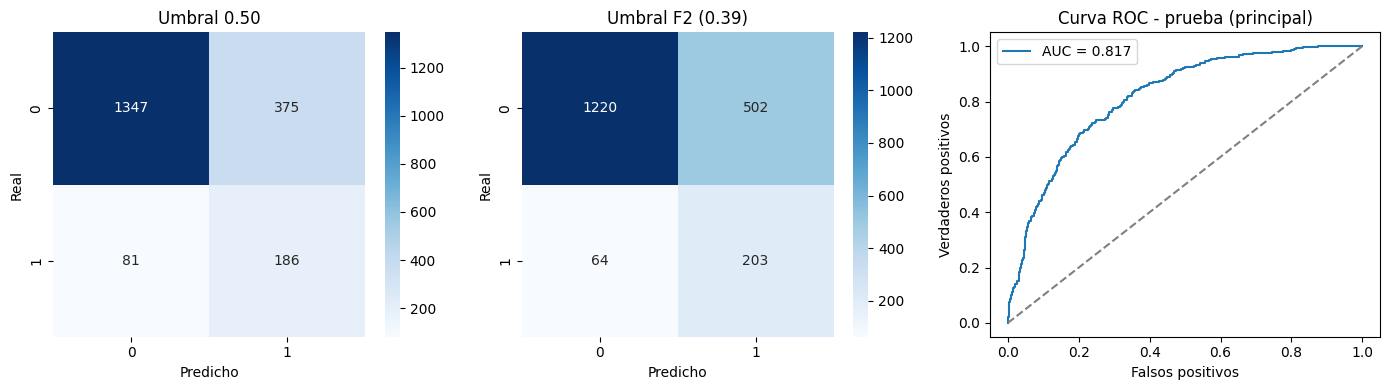

In [60]:
def plot_cm(ax, cm, titulo):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(titulo)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cm(axes[0], confusion_matrix(y_test, (proba_test_final >= 0.50).astype(int)),
        'Umbral 0.50')
plot_cm(axes[1], confusion_matrix(y_test, (proba_test_final >= UMBRAL_F2).astype(int)),
        f'Umbral F2 ({UMBRAL_F2:.2f})')

fpr, tpr, _ = roc_curve(y_test, proba_test_final)
auc_principal = roc_auc_score(y_test, proba_test_final)
axes[2].plot(fpr, tpr, label=f'AUC = {auc_principal:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray')
axes[2].set_xlabel('Falsos positivos'); axes[2].set_ylabel('Verdaderos positivos')
axes[2].set_title('Curva ROC - prueba (principal)'); axes[2].legend()
plt.tight_layout(); plt.show()


## Paso 10. Analisis con el dataset enriquecido

El dataset enriquecido anade variables de actividad fisica y de sangre (hemoglobina, ferritina, vitamina B12, vitamina D). Tiene menos registros pero mas informacion clinica.

En esta seccion repetimos el mismo flujo: K-Means exploratorio, particion, modelado con XGBoost (el modelo elegido) probando las 3 mejores variantes de SMOTE, ajuste del umbral con F2 y evaluacion final.


### 10.1 Carga del dataset enriquecido


In [61]:
enr = pd.read_csv('mineria_enriquecido.csv')
Xe = enr.drop(columns='diabetes').values
ye = enr['diabetes'].values
columnas_enr = list(enr.drop(columns='diabetes').columns)

### 10.2 K-Means exploratorio (enriquecido)

Vemos si las variables clinicas adicionales separan mejor a los grupos de
riesgo que el dataset principal.


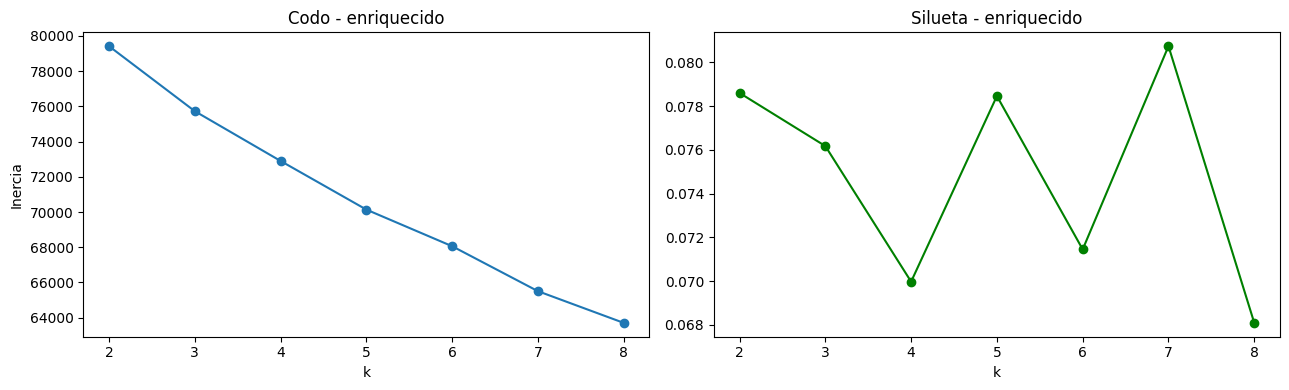

k elegido (enriquecido): 7


,personas,tasa_diabetes,edad_media,imc_medio,hb_media
cluster,,,,,
2,14,35.71,60.50,27.65,1.00
5,396,24.75,51.14,31.22,1.26
6,137,15.33,52.14,30.33,1.19
0,495,14.95,46.02,37.27,1.19
1,985,7.11,40.17,27.45,1.21
4,689,6.10,41.04,27.09,1.25
3,17,5.88,32.35,32.34,1.17


In [62]:
Xe_full = SimpleImputer(strategy='median').fit_transform(Xe)
Xe_full_s = StandardScaler().fit_transform(Xe_full)

inercias_e, siluetas_e = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEMILLA, n_init=10).fit(Xe_full_s)
    inercias_e.append(km.inertia_)
    siluetas_e.append(silhouette_score(Xe_full_s, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inercias_e, 'o-'); axes[0].set_title('Codo - enriquecido')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
axes[1].plot(list(ks), siluetas_e, 'o-', color='green')
axes[1].set_title('Silueta - enriquecido'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

k_e = list(ks)[int(np.argmax(siluetas_e))]
print('k elegido (enriquecido):', k_e)
kmeans_e = KMeans(n_clusters=k_e, random_state=SEMILLA, n_init=10).fit(Xe_full_s)
perfil_e = pd.DataFrame({
    'cluster':     kmeans_e.labels_,
    'diabetes':    ye,
    'edad':        enr['edad'],
    'imc':         enr['imc'],
    'hemoglobina': enr['hemoglobina'],
})
agrup_e = perfil_e.groupby('cluster').agg(
    personas=('diabetes', 'size'),
    tasa_diabetes=('diabetes', lambda x: round(100*x.mean(), 2)),
    edad_media=('edad', 'mean'),
    imc_medio=('imc', 'mean'),
    hb_media=('hemoglobina', 'mean'),
).round(2).sort_values('tasa_diabetes', ascending=False)
agrup_e


### 10.3 Particion y preprocesamiento del enriquecido


In [63]:
Xe_tmp, Xe_test, ye_tmp, ye_test = train_test_split(
    Xe, ye, test_size=0.20, stratify=ye, random_state=SEMILLA)
Xe_tr, Xe_val, ye_tr, ye_val = train_test_split(
    Xe_tmp, ye_tmp, test_size=0.25, stratify=ye_tmp, random_state=SEMILLA)

imp_e = SimpleImputer(strategy='median').fit(Xe_tr)
Xe_tr_i   = imp_e.transform(Xe_tr)
Xe_val_i  = imp_e.transform(Xe_val)
Xe_test_i = imp_e.transform(Xe_test)
print('Train:', Xe_tr_i.shape, ', Val:', Xe_val_i.shape, ', Test:', Xe_test_i.shape)


Train: (1639, 31) , Val: (547, 31) , Test: (547, 31)


### 10.4 XGBoost con las 3 mejores variantes de SMOTE

En lugar de probar las 6 variantes otra vez, nos quedamos con las 3 mejores (SMOTE-ENN, SMOTE, SMOTE-Tomek). Para cada una:

1. Construimos un pipeline SMOTE + XGBoost.
2. GridSearch por AUC.
3. Evaluamos sobre validacion.


In [64]:
SMOTE_TOP3 = {
    'SMOTE-ENN':   SMOTEENN(random_state=SEMILLA),
    'SMOTE':       SMOTE(random_state=SEMILLA),
    'SMOTE-Tomek': SMOTETomek(random_state=SEMILLA),
}

resultados_enr = {}
for nombre, sm in SMOTE_TOP3.items():
    pipe_e = ImbPipeline([
        ('smote',  sm),
        ('modelo', XGBClassifier(random_state=SEMILLA, eval_metric='logloss', verbosity=0)),
    ])
    busq_e = GridSearchCV(pipe_e, malla_xgb, scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=SEMILLA),
                          n_jobs=-1)
    busq_e.fit(Xe_tr_i, ye_tr)
    proba_val_e  = busq_e.best_estimator_.predict_proba(Xe_val_i)[:, 1]
    proba_test_e = busq_e.best_estimator_.predict_proba(Xe_test_i)[:, 1]
    resultados_enr[nombre] = {
        'best_params': busq_e.best_params_,
        'estimator':   busq_e.best_estimator_,
        'AUC_val':     roc_auc_score(ye_val, proba_val_e),
        'AUC_test':    roc_auc_score(ye_test, proba_test_e),
        'proba_val':   proba_val_e,
        'proba_test':  proba_test_e,
    }
    print(f'  {nombre:14s}  best={busq_e.best_params_}  '
          f'AUC_val={resultados_enr[nombre]["AUC_val"]:.3f}  '
          f'AUC_test={resultados_enr[nombre]["AUC_test"]:.3f}')


  SMOTE-ENN       best={'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}  AUC_val=0.850  AUC_test=0.868
  SMOTE           best={'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}  AUC_val=0.863  AUC_test=0.872
  SMOTE-Tomek     best={'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 100}  AUC_val=0.859  AUC_test=0.870


In [65]:
# Elegimos la combinacion con mejor AUC en validacion
mejor_smote_enr = max(resultados_enr, key=lambda n: resultados_enr[n]['AUC_val'])
print(f'\nMejor SMOTE para el enriquecido: {mejor_smote_enr}')
mejor_enr = resultados_enr[mejor_smote_enr]
proba_e_val_final  = mejor_enr['proba_val']
proba_e_test_final = mejor_enr['proba_test']



Mejor SMOTE para el enriquecido: SMOTE


### 10.5 Ajuste del umbral F2 (enriquecido)


Umbral F2-optimo (enriquecido): 0.206


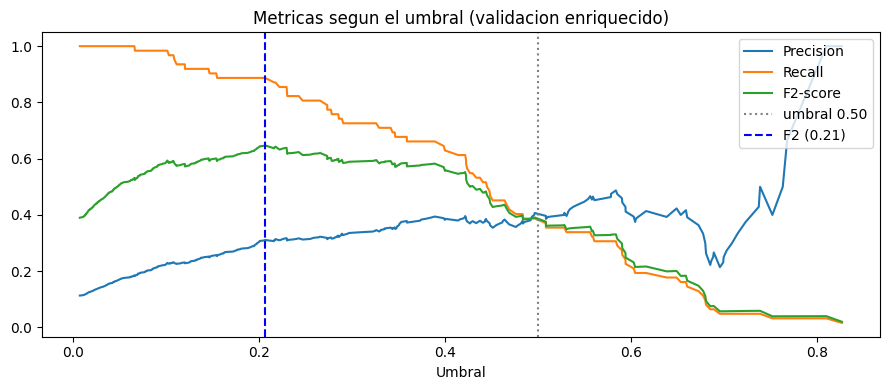

In [66]:
prec_e, rec_e, umbrales_e = precision_recall_curve(ye_val, proba_e_val_final)
f2_e = (5 * prec_e * rec_e) / (4 * prec_e + rec_e + 1e-9)
UMBRAL_F2_ENR = float(umbrales_e[int(np.argmax(f2_e[:-1]))])
print(f'Umbral F2-optimo (enriquecido): {UMBRAL_F2_ENR:.3f}')

plt.figure(figsize=(9, 4))
plt.plot(umbrales_e, prec_e[:-1], label='Precision')
plt.plot(umbrales_e, rec_e[:-1],  label='Recall')
plt.plot(umbrales_e, f2_e[:-1],   label='F2-score')
plt.axvline(0.50,          color='gray', linestyle=':',  label='umbral 0.50')
plt.axvline(UMBRAL_F2_ENR, color='blue', linestyle='--', label=f'F2 ({UMBRAL_F2_ENR:.2f})')
plt.xlabel('Umbral'); plt.title('Metricas segun el umbral (validacion enriquecido)')
plt.legend(loc='best'); plt.tight_layout(); plt.show()


### 10.6 Evaluacion final sobre prueba (enriquecido)


In [67]:
auc_enr = roc_auc_score(ye_test, proba_e_test_final)
print(f'AUC enriquecido en prueba: {auc_enr:.3f}\n')

for u in [0.50, UMBRAL_F2_ENR]:
    pred = (proba_e_test_final >= u).astype(int)
    print('=' * 60)
    print(f'Umbral {u:.2f}')
    print(classification_report(ye_test, pred,
                                target_names=['No diabetes', 'Diabetes']))


AUC enriquecido en prueba: 0.872

Umbral 0.50
              precision    recall  f1-score   support

 No diabetes       0.94      0.94      0.94       485
    Diabetes       0.50      0.50      0.50        62

    accuracy                           0.89       547
   macro avg       0.72      0.72      0.72       547
weighted avg       0.89      0.89      0.89       547

Umbral 0.21
              precision    recall  f1-score   support

 No diabetes       0.97      0.74      0.84       485
    Diabetes       0.28      0.82      0.42        62

    accuracy                           0.75       547
   macro avg       0.63      0.78      0.63       547
weighted avg       0.89      0.75      0.79       547



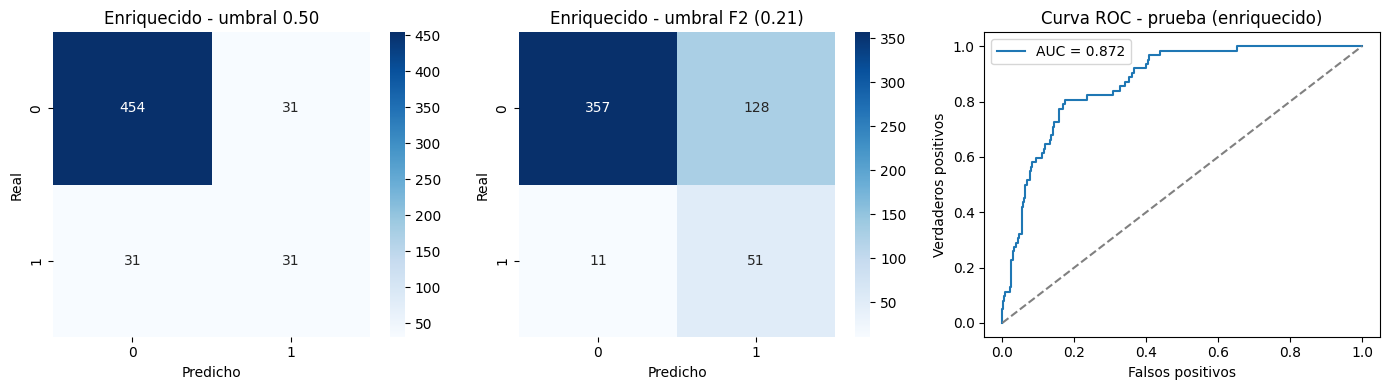

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_cm(axes[0], confusion_matrix(ye_test, (proba_e_test_final >= 0.50).astype(int)),
        'Enriquecido - umbral 0.50')
plot_cm(axes[1], confusion_matrix(ye_test, (proba_e_test_final >= UMBRAL_F2_ENR).astype(int)),
        f'Enriquecido - umbral F2 ({UMBRAL_F2_ENR:.2f})')

fpr_e, tpr_e, _ = roc_curve(ye_test, proba_e_test_final)
axes[2].plot(fpr_e, tpr_e, label=f'AUC = {auc_enr:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray')
axes[2].set_xlabel('Falsos positivos'); axes[2].set_ylabel('Verdaderos positivos')
axes[2].set_title('Curva ROC - prueba (enriquecido)'); axes[2].legend()
plt.tight_layout(); plt.show()


## Paso 11. Tabla comparativa final


In [69]:
def metricas_full(y_true, proba, u):
    pred = (proba >= u).astype(int)
    return {'accuracy':  accuracy_score(y_true, pred),
            'precision': precision_score(y_true, pred),
            'recall':    recall_score(y_true, pred),
            'f1':        f1_score(y_true, pred),
            'auc':       roc_auc_score(y_true, proba)}

filas = {
    # Principal: 3 modelos baseline + XGBoost con 2 umbrales
    'Principal | 1. Arbol simple (sin SMOTE)':              metricas_full(y_test, proba_arbol_simple, 0.50),
    'Principal | 2. Arbol ajustado + SMOTE-ENN':            metricas_full(y_test, proba_arbol_tuneado, 0.50),
    'Principal | 3. KNN + SMOTE-ENN':                       metricas_full(y_test, proba_knn, 0.50),
    'Principal | 4. XGBoost (umbral 0.50)':                 metricas_full(y_test, proba_test_final, 0.50),
    f'Principal | 4. XGBoost (umbral F2 {UMBRAL_F2:.2f})':  metricas_full(y_test, proba_test_final, UMBRAL_F2),
    # Enriquecido: XGBoost con 2 umbrales
    f'Enriquecido | XGBoost + {mejor_smote_enr} (umbral 0.50)':                 metricas_full(ye_test, proba_e_test_final, 0.50),
    f'Enriquecido | XGBoost + {mejor_smote_enr} (umbral F2 {UMBRAL_F2_ENR:.2f})': metricas_full(ye_test, proba_e_test_final, UMBRAL_F2_ENR),
}
tabla_final = pd.DataFrame(filas).T.round(3)
tabla_final


,accuracy,precision,recall,f1,auc
Principal | 1. Arbol simple (sin SMOTE),0.793,0.274,0.330,0.299,0.597
Principal | 2. Arbol ajustado + SMOTE-ENN,0.736,0.293,0.685,0.410,0.785
Principal | 3. KNN + SMOTE-ENN,0.590,0.230,0.876,0.365,0.790
Principal | 4. XGBoost (umbral 0.50),0.771,0.332,0.697,0.449,0.817
Principal | 4. XGBoost (umbral F2 0.39),0.715,0.288,0.760,0.418,0.817
Enriquecido | XGBoost + SMOTE (umbral 0.50),0.887,0.500,0.500,0.500,0.872
Enriquecido | XGBoost + SMOTE (umbral F2 0.21),0.746,0.285,0.823,0.423,0.872




#Modelo recomendado

El modelo recomendado es XGBoost utilizando el dataset enriquecido con SMOTE y un umbral de clasificación de 0.21 (optimizado con F2). La elección se debe a que presentó el mejor balance entre las métricas evaluadas, manteniendo un recall superior a 0.80.

El objetivo principal era priorizar el recall sin que la precisión fuera excesivamente baja. Aunque la precisión aún esta algo baja, este modelo obtuvo la mejor precisión entre aquellos con recall alto. Además, presentó el segundo mejor recall y el mejor AUC entre los modelos evaluados.
